In [1]:
import torch
from v1_sliding_diffusion import Diffusion
from v1_model import ContinuousMotionModel
from utils.debugger import Debugger
from v1_training_loop import train
from v1_sliding_diffusion import Diffusion
from pose_encoder.pose_encoder import PoseEncoder
from pose_encoder.advanced_pose_encoder import AdvancedPoseEncoder
from torch.utils.data import DataLoader
from dataset.dataset import *
import wandb
import utils.utils as utils

wandb.login()

device = utils.get_device()

TypeError: Cannot create a consistent method resolution
order (MRO) for bases Module, PoseEncoder

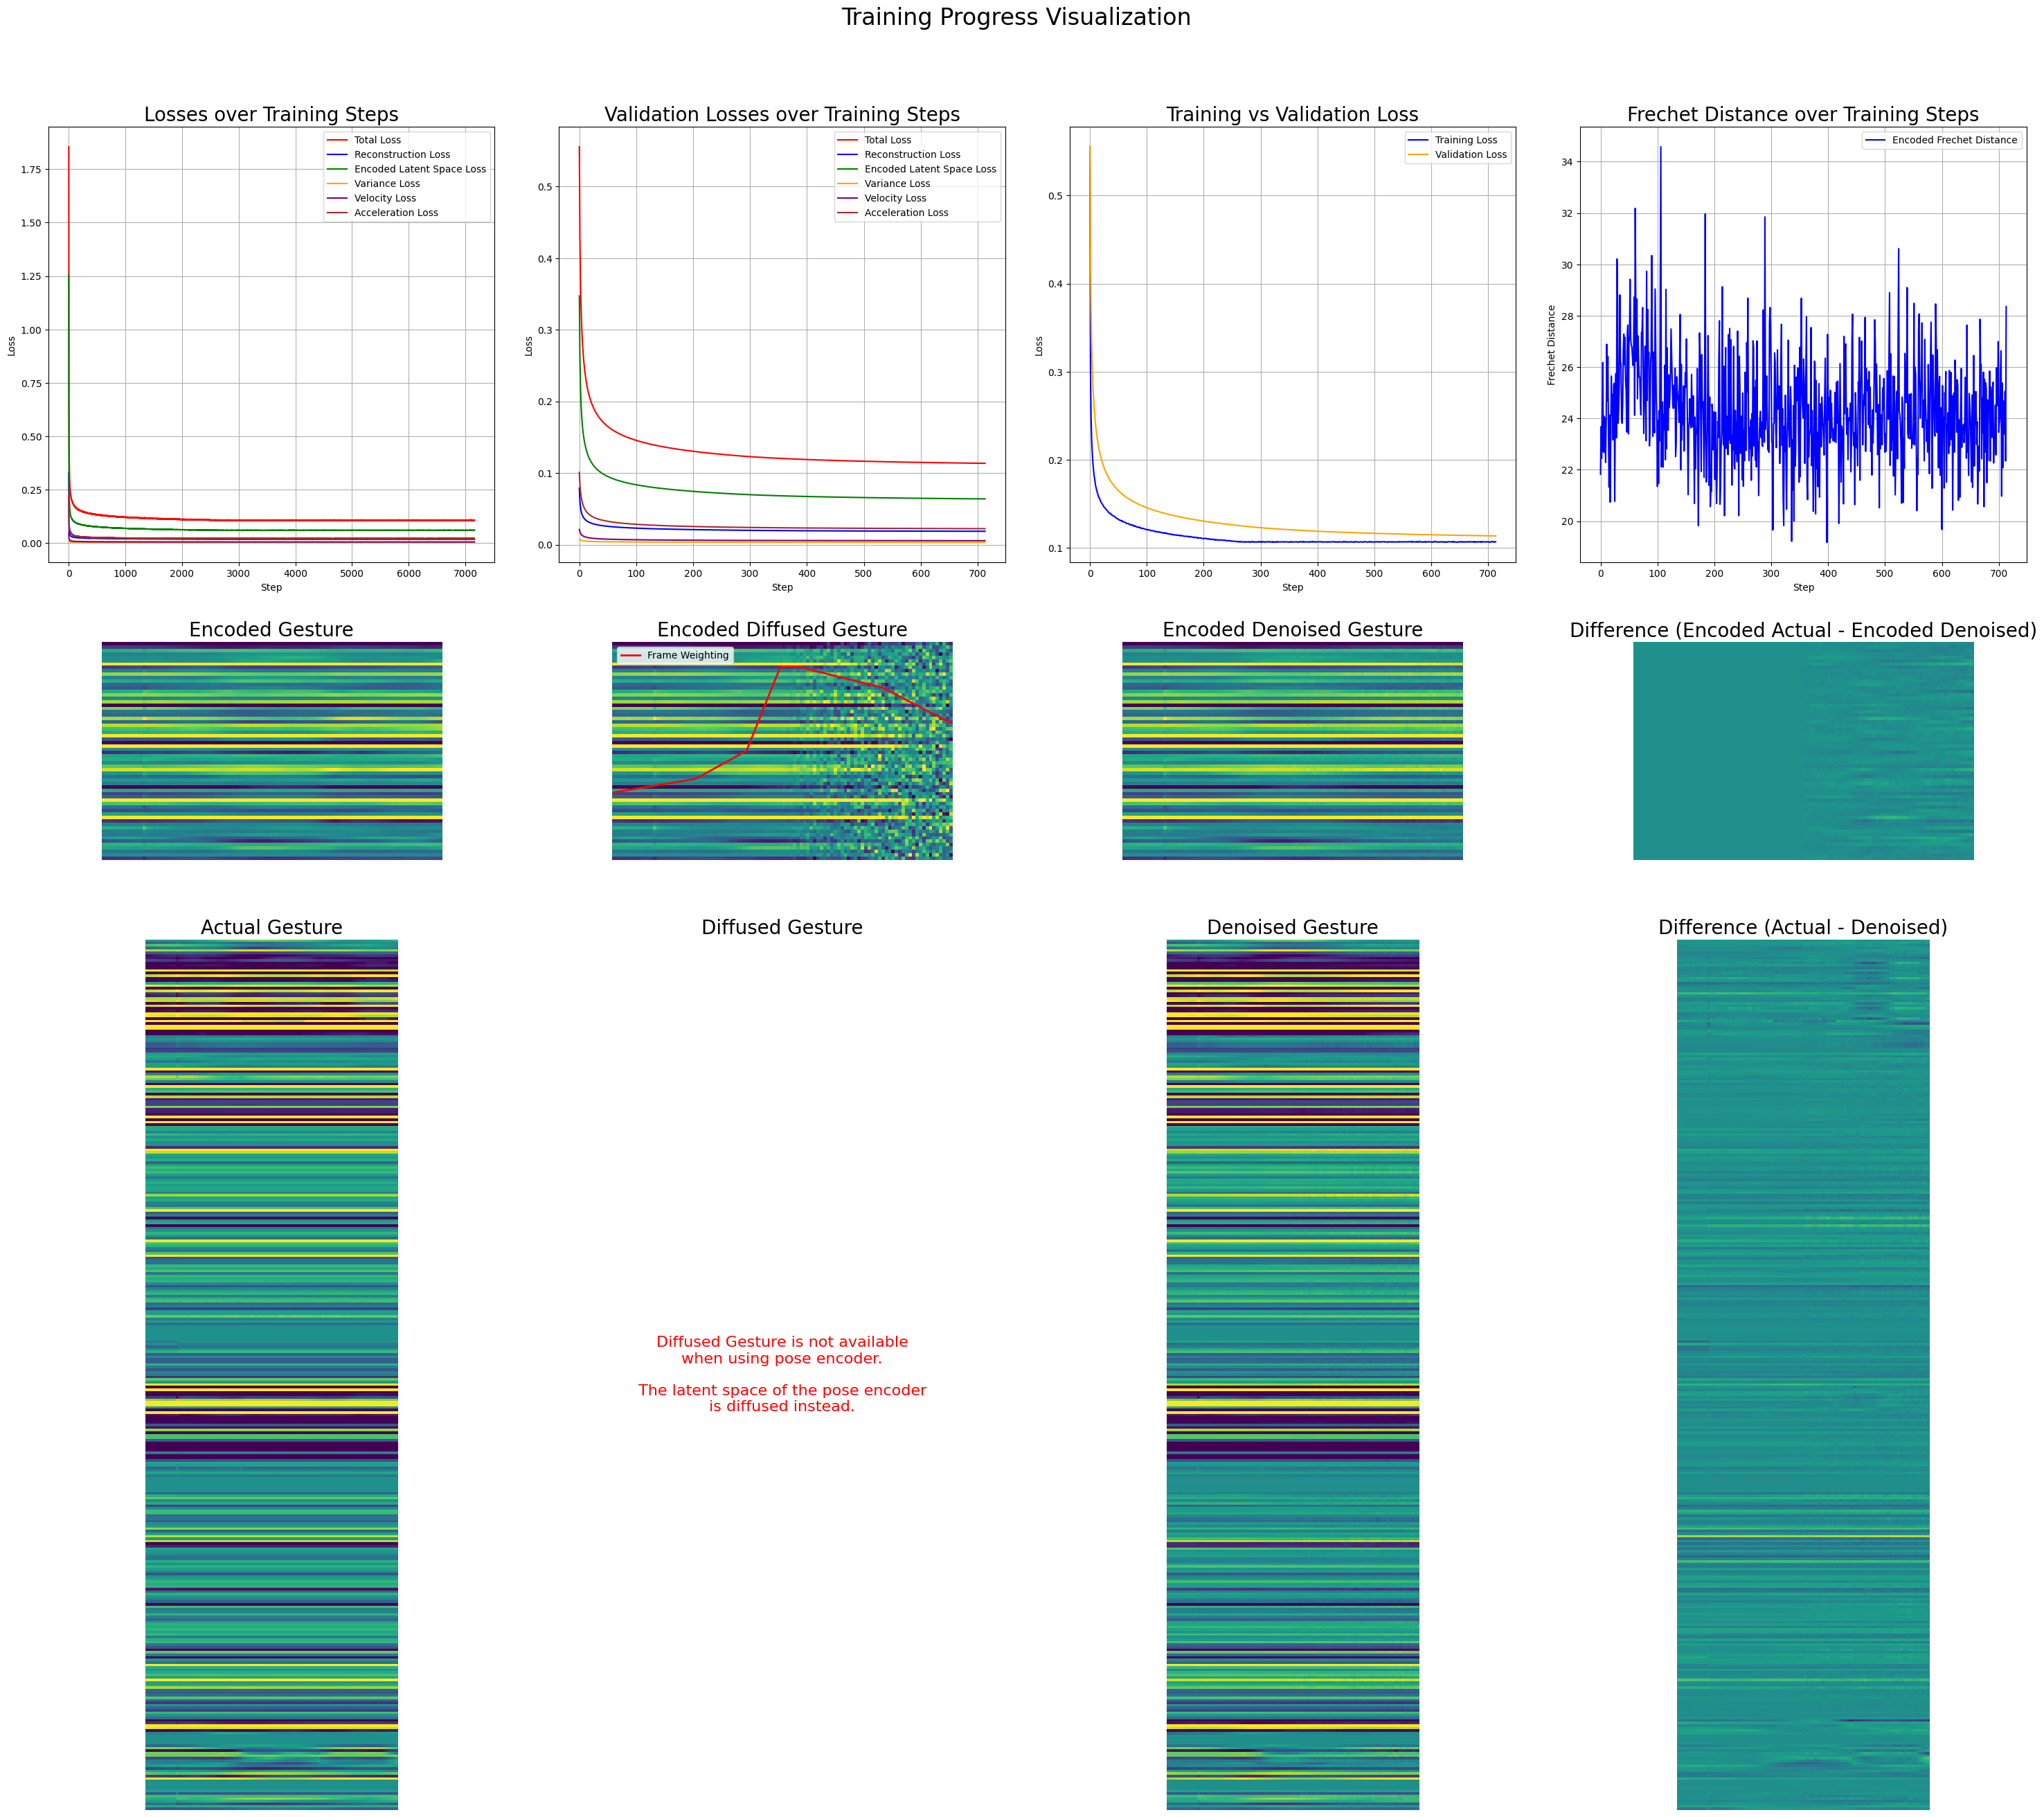

Epoch 717/1000:   8%|▊         | 81/1000 [00:07<01:28, 10.41it/s, Training loss=0.10302234441041946, Last epoch loss=0.106863539673388, Frechet distance=28.358162110572636]


KeyboardInterrupt: 

In [ ]:
# tmp dataset to get a reference to the skeleton. TODO: find a better way to do this
skeleton_dataset = GPUDataset(
    consolidated_file="dataset/genea2023_dataset/toy/main-agent/consolidated.npz",
    seq_length=1,
    seed_length=0,
    batch_size=1,
    epoch_length=1
)

train(
    experiment_collection_name = "first_tests",
    upload_model_check_point = False, # should upload the model checkpoint to wandb
    model_checkpoint_dir = "v1_models",
    model = ContinuousMotionModel(
        diffusion = Diffusion(
            device = device,
            num_of_pre_timestep_frames = 50,
            num_of_timestep_frames = 50,
            num_of_post_timestep_frames = 0,
            noise_schedule = Diffusion.linear_schedule(0.00015, 0.15)),
        pose_encoder = AdvancedPoseEncoder(
            pose_dim=345,
            component_definitions = {
                # Preserved (no encoding/decoding)
                'world_pos': {
                    'bone_names': ['body_world'],
                    'type': 'preserve',
                    'use_position': True
                },
                'left_hand_rot': {
                    'bone_name': 'b_l_wrist',
                    'type': 'world_preserve_after_ik'
                },
                'right_hand_rot': {
                    'bone_name': 'b_r_wrist',
                    'type': 'world_preserve_after_ik'
                },
                'left_foot_rot': {
                    'bone_name': 'b_l_foot',
                    'type': 'world_preserve_after_ik'
                },
                'right_foot_rot': {
                    'bone_name': 'b_r_foot',
                    'type': 'world_preserve_after_ik'
                },
                # Auto-encoded components - explicit bone lists
                'spine_shoulders_head': {
                    'bone_names': [
                        'b_root', 'b_spine0', 'b_spine1', 'b_spine2', 'b_spine3',
                        'b_l_shoulder', 'b_r_shoulder', 'b_neck0', 'b_head'
                    ],
                    'type': 'encode',
                    'z_dim': 5
                },
                'left_hand_fingers': {
                    'bone_names': [
                        # Left thumb
                        'b_l_thumb0', 'b_l_thumb1', 'b_l_thumb2', 'b_l_thumb3',
                        # Left fingers  
                        'b_l_index1', 'b_l_index2', 'b_l_index3',
                        'b_l_middle1', 'b_l_middle2', 'b_l_middle3',
                        'b_l_ring1', 'b_l_ring2', 'b_l_ring3',
                        'b_l_pinky1', 'b_l_pinky2', 'b_l_pinky3'
                    ],
                    'type': 'encode',
                    'z_dim': 8
                },
                'right_hand_fingers': {
                    'bone_names': [
                        # Right thumb
                        'b_r_thumb0', 'b_r_thumb1', 'b_r_thumb2', 'b_r_thumb3',
                        # Right fingers
                        'b_r_index1', 'b_r_index2', 'b_r_index3',
                        'b_r_middle1', 'b_r_middle2', 'b_r_middle3',
                        'b_r_ring1', 'b_r_ring2', 'b_r_ring3',
                        'b_r_pinky1', 'b_r_pinky2', 'b_r_pinky3'
                    ],
                    'type': 'encode',
                    'z_dim': 8
                },
                # IK components - using skeleton's enhanced chain info
                'left_arm_ik': {
                    'type': 'ik',
                    'chain_joints': ['b_l_arm', 'b_l_forearm'],
                    'end_effector': 'b_l_wrist',
                    'z_dim': 4,  # 3 for target position + 1 swivel rotation
                    'twist_joint': 'b_l_arm_twist',
                    'chain_parent': 'b_l_shoulder',
                    'bone1_forward_dir': [0.9993694424629211, -0.023177823051810265, -0.026897454634308815],
                    'bone1_up_dir': [-0.02316943369805813, -0.9997313618659973, 0.0006235920009203255],
                    'bone2_forward_dir': [0.9993695020675659, -0.02317732758820057, -0.026897458359599113],
                    'bone2_up_dir': [-0.023168936371803284, -0.9997313618659973, 0.0006235786713659763],
                },
                'right_arm_ik': {
                    'type': 'ik',
                    'chain_joints': ['b_r_arm', 'b_r_forearm'],
                    'end_effector': 'b_r_wrist',
                    'z_dim': 4,
                    'twist_joint': 'b_r_arm_twist',
                    'chain_parent': 'b_r_shoulder',
                    'bone1_forward_dir': [-0.9992618560791016, -0.028031472116708755, -0.026267891749739647],
                    'bone1_up_dir': [0.02802179381251335, -0.9996070861816406, 0.0007366171339526772],
                    'bone2_forward_dir': [-0.9992617964744568, -0.028031865134835243, -0.02626790478825569],
                    'bone2_up_dir': [0.02802218683063984, -0.9996070265769958, 0.0007366279023699462],
                },
                'left_leg_ik': {
                    'type': 'ik',
                    'chain_joints': ['b_l_upleg', 'b_l_leg'],
                    'end_effector': 'b_l_foot',
                    'z_dim': 4,
                    'chain_parent': 'b_root',
                    'bone1_forward_dir': [0.0, -0.9999752044677734, 0.007038275245577097],
                    'bone1_up_dir': [0.0, 0.007038275711238384, 0.9999752640724182],
                    'bone2_forward_dir': [0.0, -0.996783435344696, -0.0801420658826828],
                    'bone2_up_dir': [0.0, 0.0801420658826828, -0.996783435344696],
                },
                'right_leg_ik': {
                    'type': 'ik',
                    'chain_joints': ['b_r_upleg', 'b_r_leg'],
                    'end_effector': 'b_r_foot',
                    'z_dim': 4,
                    'chain_parent': 'b_root',
                    'bone1_forward_dir': [0.0, -0.9999904632568359, 0.004357356112450361],
                    'bone1_up_dir': [0.0, 0.0043573565781116486, 0.9999905228614807],
                    'bone2_forward_dir': [0.0, -0.996783435344696, -0.0801420733332634],
                    'bone2_up_dir': [0.0, 0.0801420733332634, -0.996783435344696],
                }
            },
            skeleton = skeleton_dataset.skeleton,
            device = utils.get_device(),
            checkpoint_path="advanced_pose_encoder_64.pth"
        ),
        number_of_styles = 17,
        n_gesture_length = 100,
        audio_features_per_frame = 37,
        pose_features_per_frame = 64,
        condition_mask_probabilty = 0.1,
        number_of_attention_heads = 8,
        predict_full_duration = False,
        debugger = Debugger(
            on = False, 
            keys_for_printing_while_running = ["ALL"]
        ),
        device = device
    ),
    device = device,
    training_loader = DataLoader(
            GPUDataset(
                consolidated_file = "dataset/genea2023_dataset/trn/main-agent/consolidated.npz",
                seq_length = 100,
                seed_length = 0,
                batch_size = 256,
                epoch_length = 1000,
                device = device
            ),
            batch_size = 1,
            num_workers = 0,
            pin_memory = False  
        ),
    val_loader=DataLoader(
            GPUDataset(
                consolidated_file = "dataset/genea2023_dataset/val/main-agent/consolidated.npz",
                seq_length = 100,
                seed_length = 0,
                batch_size = 64,
                epoch_length = 30,
                device = device
            ),
            batch_size = 1,
            num_workers = 0,
            pin_memory = False
        ),
    num_epochs = 1000,
    learning_rate = 0.000025,
    reconstruction_loss_weight = 1.0,
    variance_loss_weight = 0.1,
    velocity_loss_weight = 1.0,
    acceleration_loss_weight = 2.0,
    latent_space_loss_weight = 4.0,
    category_weighting = {
        'fingers': 0.1,
        'arms': 2.0,
        'legs': 1.0,
        'spine': 2.0,
        'head': 1.0,
        'root': 2.0
    },
    frame_weighting_segments_info = [
        (0.1, 0.2, 25),
        (0.2, 0.4, 40),
        (0.4, 1.0, 50),
        (1.0, 1.0, 55),
        (1.0, 0.85, 80),
        (0.85, 0.6, 100)
    ],
    visualize_step = 100,
)